# UniverSeg XAI – Grad-CAM & SHAP

This notebook runs sequentially on two datasets:
1. **ISIC** – skin lesion segmentation
2. **Kvasir** – polyp segmentation

For each dataset:
- A random query image is selected and fed to the model with 3 support images.
- **Grad-CAM** and **SHAP GradientExplainer** are computed.
- Results are displayed as a 5-column panel and saved to Drive.

**No bulk download** – Drive is mounted and files are read only when needed.

## Cell 1 – Install packages

> **Private repo:** uncomment the `GITHUB_TOKEN` line and paste your token.  
> **Public repo:** leave the token line commented out.

In [1]:
import os, subprocess, sys

# If the repo is public, leave the token line commented out:
# GITHUB_TOKEN = "ghp_..."   # <-- paste your token here for private repos

REPO = "canzorlu-eng/UniverSeg"
DEST = "/content/UniverSeg"

if 'GITHUB_TOKEN' in dir():
    clone_url = f"https://{GITHUB_TOKEN}@github.com/{REPO}.git"
else:
    clone_url = f"https://github.com/{REPO}.git"

if not os.path.isdir(DEST):
    subprocess.run(["git", "clone", clone_url, DEST, "-q"], check=True)
    print("Repo cloned.")
else:
    print("Repo already exists, skipping clone.")

subprocess.run([sys.executable, "-m", "pip", "install", "-e", DEST, "-q"], check=True)
subprocess.run([sys.executable, "-m", "pip", "install", "shap", "-q"], check=True)
print("✓ Setup complete.")

Repo cloned.
✓ Setup complete.


## Cell 2 – Mount Google Drive

**Before running this cell:**
1. Open the [shared Drive folder](https://drive.google.com/drive/folders/1_86qGdBiYRk0_I6xcl2mUtfulBIzf5tg).
2. Right-click the folder → **"Add shortcut to Drive"** → **My Drive** → OK.
3. Run this cell and grant access.

In [2]:
from google.colab import drive
drive.mount('/content/drive')
print("✓ Drive mounted.")

Mounted at /content/drive
✓ Drive mounted.


## Cell 3 – Path configuration

Set `DATA_ROOT` to the name of the data folder in your Drive.  
If you added the shortcut to My Drive, the folder is most likely named `data`.

In [3]:
import os

# ── Adjust if your folder has a different name ────────────────────────────────
DATA_ROOT  = "/content/drive/MyDrive/data"         # path to the data folder in Drive
OUTPUT_DIR = "/content/drive/MyDrive/xai_outputs"  # results will be saved here
# ─────────────────────────────────────────────────────────────────────────────

ISIC_IMAGES   = f"{DATA_ROOT}/isic/images"
ISIC_MASKS    = f"{DATA_ROOT}/isic/masks"
KVASIR_IMAGES = f"{DATA_ROOT}/kvasir/images"
KVASIR_MASKS  = f"{DATA_ROOT}/kvasir/masks"

os.makedirs(OUTPUT_DIR, exist_ok=True)

all_ok = True
for path, label in [
    (ISIC_IMAGES,   "ISIC images"),
    (ISIC_MASKS,    "ISIC masks"),
    (KVASIR_IMAGES, "Kvasir images"),
    (KVASIR_MASKS,  "Kvasir masks"),
]:
    exists = os.path.isdir(path)
    if exists:
        count = len([f for f in os.listdir(path) if not f.startswith('.')])
        print(f"✓  {label}: {path}  ({count} files)")
    else:
        print(f"✗  {label}: NOT FOUND -> {path}")
        all_ok = False

if all_ok:
    print("\n✓ All directories found.")
else:
    print("\n✗ Some directories are missing – check DATA_ROOT!")

✓  ISIC images: /content/drive/MyDrive/data/isic/images  (2594 files)
✓  ISIC masks: /content/drive/MyDrive/data/isic/masks  (2594 files)
✓  Kvasir images: /content/drive/MyDrive/data/kvasir/images  (1000 files)
✓  Kvasir masks: /content/drive/MyDrive/data/kvasir/masks  (1000 files)

✓ All directories found.


## Cell 4 – Imports and model initialization

In [4]:
%matplotlib inline
import random, time, sys
import numpy as np
import torch
import matplotlib.pyplot as plt
from IPython.display import Image as IPyImage, display
from torch.utils.data import DataLoader
from torchvision import transforms

if "/content/UniverSeg" not in sys.path:
    sys.path.insert(0, "/content/UniverSeg")

from universeg import universeg
from universeg.xai import (
    MedicalFewShotDataset,
    SegGradCAM,
    run_shap_gradient,
    save_combined_xai_panel,
    set_seed,
)

BACKGROUND_SIZE = 8

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

print("Loading model (pretrained weights are downloaded on first run)...")
model = universeg(pretrained=True).to(device)
model.eval()
print("✓ Model ready.")

Device: cuda
Loading model (pretrained weights are downloaded on first run)...
Downloading: "https://github.com/JJGO/UniverSeg/releases/download/weights/universeg_v1_nf64_ss64_STA.pt" to /root/.cache/torch/hub/checkpoints/universeg_v1_nf64_ss64_STA.pt


100%|██████████| 4.53M/4.53M [00:00<00:00, 75.1MB/s]


✓ Model ready.


## Cell 5 – Pipeline function

In [5]:
def sample_background_queries(dataset, n, dev):
    idxs = random.sample(range(len(dataset)), min(n, len(dataset)))
    imgs = [dataset._load_item(i)[0] for i in idxs]
    return torch.stack(imgs).to(dev).detach()


def run_xai_pipeline(dataset_type, image_dir, mask_dir, seed=None, num_images=5):
    """
    Run the full XAI pipeline on `num_images` randomly selected queries.
      Step A : base forward pass (prediction mask)
      Step B : Grad-CAM on dec_last layer
      Step C : SHAP GradientExplainer
    Saves each result panel to Drive and returns the list of output paths.
    """
    current_seed = seed if seed is not None else int(time.time())
    print(f"\n{'='*60}")
    print(f"  Dataset    : {dataset_type.upper()}")
    print(f"  Num images : {num_images}")
    print(f"  Seed       : {current_seed}")
    print(f"{'='*60}")

    set_seed(current_seed)

    transform = transforms.Compose([
        transforms.Resize((128, 128)),
        transforms.ToTensor(),
    ])

    dataset = MedicalFewShotDataset(
        image_dir=image_dir,
        mask_dir=mask_dir,
        dataset_type=dataset_type,
        support_size=3,
        transform=transform,
    )
    print(f"Dataset size : {len(dataset)} images")

    loader = DataLoader(dataset, batch_size=1, shuffle=True)
    out_paths = []

    for i, (support_imgs, support_masks, query_img, query_mask, query_name) in enumerate(loader):
        if i >= num_images:
            break

        image_name = query_name[0]
        print(f"\n[{i+1}/{num_images}] Query image: {image_name}")

        query_img     = query_img.to(device).detach().clone()
        support_imgs  = support_imgs.to(device).detach().clone()
        support_masks = support_masks.to(device).detach().clone()
        query_mask_np = query_mask.cpu().squeeze().numpy()
        query_np      = query_img.cpu().squeeze().numpy()

        print(f"  Step 0 : sampling {BACKGROUND_SIZE} background queries...")
        background_queries = sample_background_queries(dataset, BACKGROUND_SIZE, device)

        print("  Step A : base forward pass...")
        with torch.no_grad():
            base_logits           = model(query_img, support_imgs, support_masks)
            base_pred_tensor      = torch.sigmoid(base_logits).detach()
            base_pred             = base_pred_tensor.cpu().squeeze().numpy()
            frozen_base_pred_mask = (base_pred_tensor > 0.5).float()

        print("  Step B : Grad-CAM (dec_last)...")
        with SegGradCAM(model, target_layer="dec_last") as gradcam_fn:
            gradcam_map, _ = gradcam_fn(query_img, support_imgs, support_masks)
        model.eval()

        print("  Step C : SHAP GradientExplainer (may take a few minutes)...")
        t0 = time.time()
        shap_map = run_shap_gradient(
            model=model,
            query_img=query_img,
            support_imgs=support_imgs,
            support_masks=support_masks,
            background_queries=background_queries,
            frozen_base_pred_mask=frozen_base_pred_mask,
            device=device,
        )
        elapsed = time.time() - t0
        print(f"  SHAP done ({elapsed:.1f}s)  "
              f"range: [{shap_map.min():.3e}, {shap_map.max():.3e}]")

        stem     = image_name.rsplit('.', 1)[0]
        filename = f"xai_panel_{dataset_type}_{stem}_seed_{current_seed}.png"
        out_path = os.path.join(OUTPUT_DIR, filename)

        save_combined_xai_panel(
            query=query_np,
            gt=query_mask_np,
            pred=base_pred,
            gradcam=gradcam_map,
            shap_map=shap_map,
            out_path=out_path,
            title=image_name,
        )
        print(f"  ✓ Saved: {out_path}")
        out_paths.append(out_path)

    return out_paths

print("✓ Functions defined.")

✓ Functions defined.


---
## Section 1 — ISIC Dataset (Skin Lesion)

Runs the same logic as `xai_unified.py` — data is read from Drive on demand and the result panel is displayed inline.


  Dataset    : ISIC
  Num images : 1
  Seed       : 1781296229
Dataset size : 2594 images

[1/1] Query image: ISIC_0014486.jpg
  Step 0 : sampling 8 background queries...
  Step A : base forward pass...
  Step B : Grad-CAM (dec_last)...
  Step C : SHAP GradientExplainer (may take a few minutes)...
  SHAP done (7.7s)  range: [-7.857e+00, 7.344e+00]
  ✓ Saved: /content/drive/MyDrive/xai_outputs/xai_panel_isic_ISIC_0014486_seed_1781296229.png

── ISIC Result Panels ──


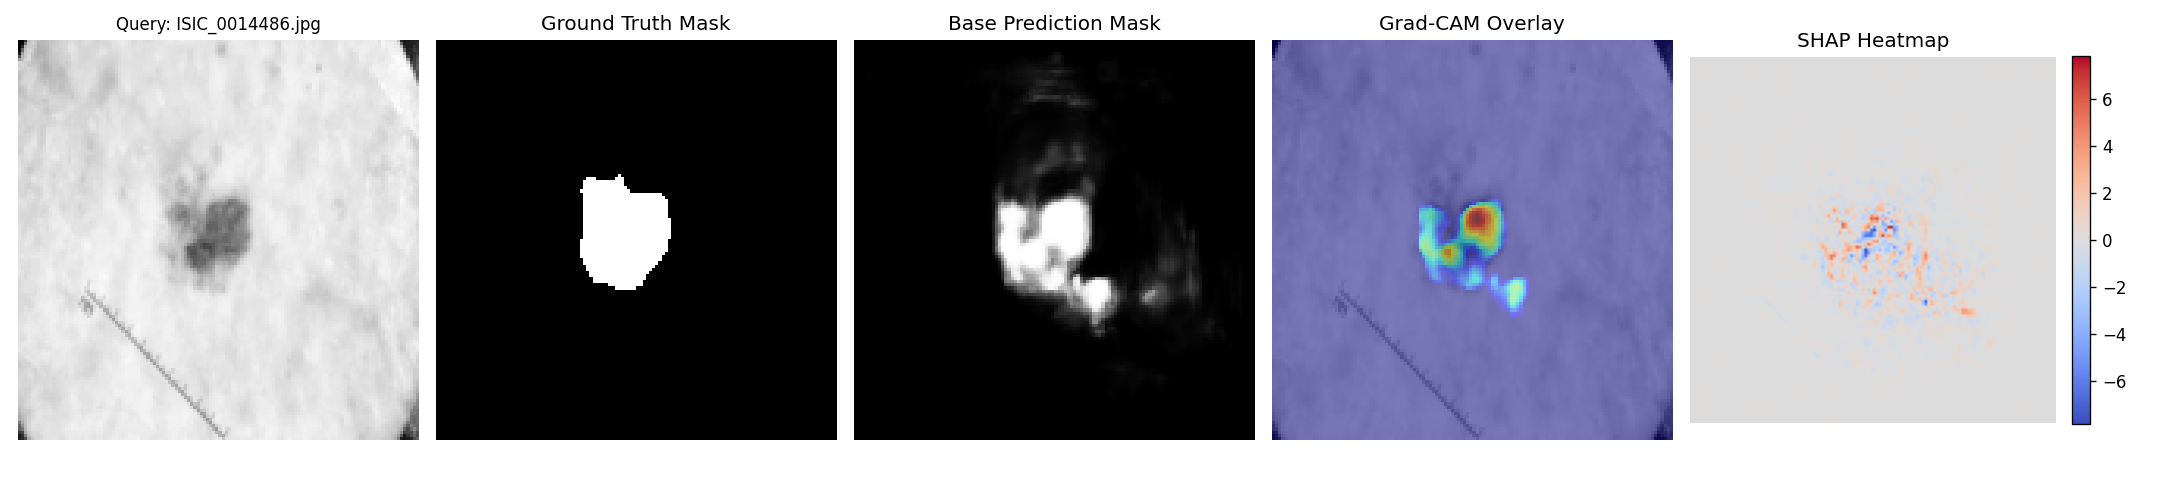

In [6]:
TARGET_SEED_ISIC = None   # set to an int for reproducibility (e.g. 1718345), None = random

isic_outs = run_xai_pipeline(
    dataset_type="isic",
    image_dir=ISIC_IMAGES,
    mask_dir=ISIC_MASKS,
    seed=TARGET_SEED_ISIC,
    num_images=1,
)

print("\n── ISIC Result Panels ──")
for path in isic_outs:
    display(IPyImage(filename=path))

---
## Section 2 — Kvasir Dataset (Polyp)

Runs the same logic as `xai_unified_kvasir.py`.


  Dataset    : KVASIR
  Num images : 1
  Seed       : 1781296256
Dataset size : 1000 images

[1/1] Query image: cju8buos5rz9b08715lfr0f4f.jpg
  Step 0 : sampling 8 background queries...
  Step A : base forward pass...
  Step B : Grad-CAM (dec_last)...
  Step C : SHAP GradientExplainer (may take a few minutes)...
  SHAP done (3.5s)  range: [-3.809e+01, 5.382e+01]
  ✓ Saved: /content/drive/MyDrive/xai_outputs/xai_panel_kvasir_cju8buos5rz9b08715lfr0f4f_seed_1781296256.png

── Kvasir Result Panels ──


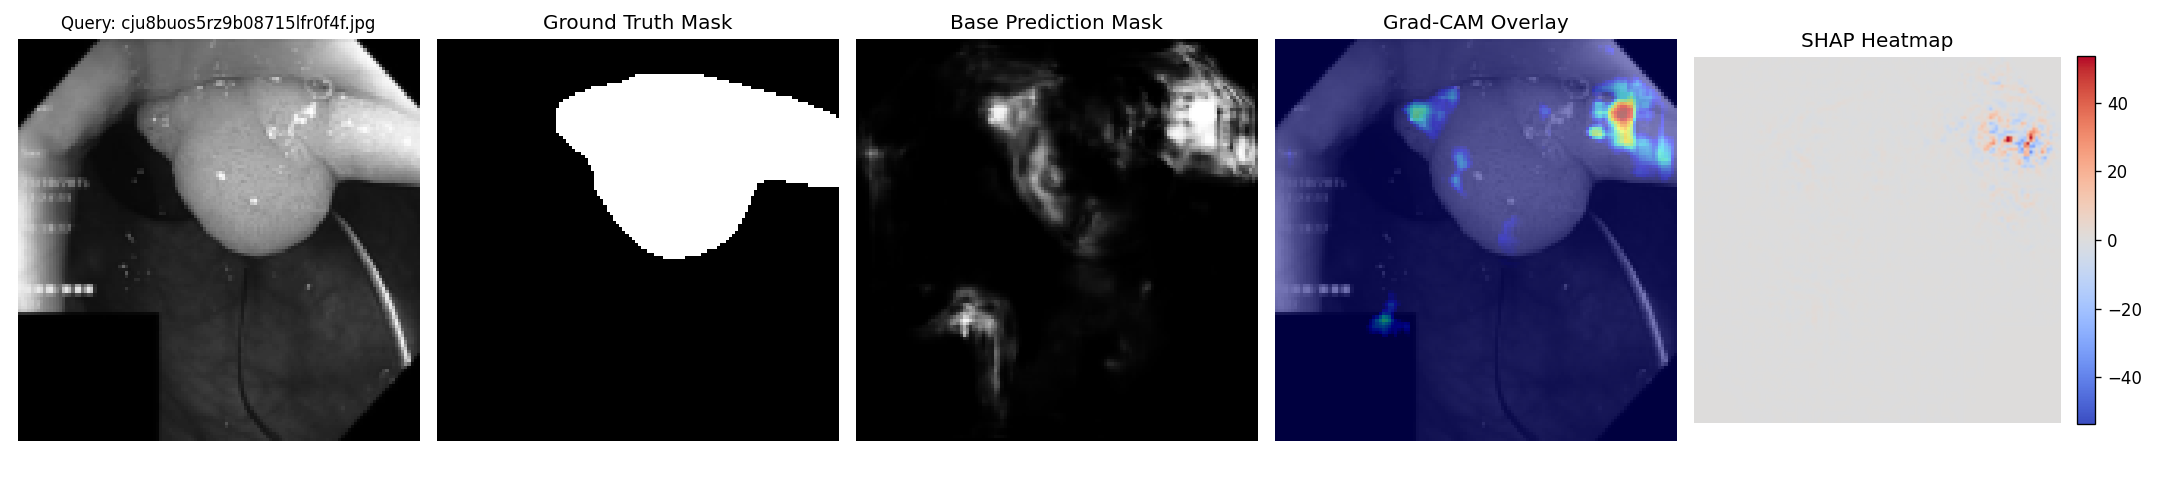

In [7]:
TARGET_SEED_KVASIR = None   # set to an int for reproducibility, None = random

kvasir_outs = run_xai_pipeline(
    dataset_type="kvasir",
    image_dir=KVASIR_IMAGES,
    mask_dir=KVASIR_MASKS,
    seed=TARGET_SEED_KVASIR,
    num_images=1,
)

print("\n── Kvasir Result Panels ──")
for path in kvasir_outs:
    display(IPyImage(filename=path))

---
## Summary

In [8]:
print(f"Saved XAI panels ({OUTPUT_DIR}):")
for f in sorted(os.listdir(OUTPUT_DIR)):
    if f.endswith('.png'):
        size_kb = os.path.getsize(os.path.join(OUTPUT_DIR, f)) / 1024
        print(f"  {f}  ({size_kb:.0f} KB)")

Saved XAI panels (/content/drive/MyDrive/xai_outputs):
  xai_panel_isic_ISIC_0000292_seed_1781295250.png  (248 KB)
  xai_panel_isic_ISIC_0010092_seed_1781295821.png  (223 KB)
  xai_panel_isic_ISIC_0012660_seed_1781294865.png  (233 KB)
  xai_panel_isic_ISIC_0014410_seed_1781295821.png  (234 KB)
  xai_panel_isic_ISIC_0014486_seed_1781296229.png  (165 KB)
  xai_panel_isic_ISIC_0015312_seed_1781294351.png  (302 KB)
  xai_panel_isic_ISIC_0016005_seed_1781295250.png  (224 KB)
  xai_panel_kvasir_cju77vvcwzcm50850lzoykuva_seed_1781294899.png  (166 KB)
  xai_panel_kvasir_cju7ea4om2l910801bohqjccy_seed_1781294373.png  (225 KB)
  xai_panel_kvasir_cju8buos5rz9b08715lfr0f4f_seed_1781296256.png  (153 KB)
